In [10]:
#Importamos librerías requeridas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
#Carga desde un archivo .csv sin indice
data = pd.read_csv('Analisis GAC Full7agosto 2026(Resumen).csv')
data

,RESUMEN AL CUMPLIMIENTO DE OBJETIVOS,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 51,Unnamed: 52,Unnamed: 53,Unnamed: 54,Unnamed: 55,Unnamed: 56,Unnamed: 57,Unnamed: 58,Unnamed: 59,Unnamed: 60
0,Resumen de Operaciones\nDto. Autos Nuevos,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,Promedio Mes,"1,109",653,27,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,"33,275","19,582",822,NaN,833,NaN,NaN,4.43%,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Año,Mes,Leads,Efectivos,Ventas Reportadas,Obj Ventas,Ventas Real,% CAL,Obj Conversion,Conversion,...,NaN,NaN,NaN,NaN,NaN,Proyeccion,Diferencia,NaN,NaN,NaN
5,2024,Febrero,543,389,12,20,12,60%,3.5%,3.08%,...,NaN,NaN,ajuste sin marca,NaN,NaN,-,-,NaN,NaN,NaN
6,NaN,Marzo,178,128,7,20,7,35%,3.5%,5.47%,...,NaN,Marca,38%,51%,65.000000,-,-,NaN,NaN,NaN
7,NaN,Abril,416,288,8,20,8,40%,3.5%,2.78%,...,743.548087,1212,22,NaN,1440.540073,-,-,NaN,Crédito,Contado
8,NaN,Mayo,422,274,13,20,13,65%,3.5%,4.74%,...,NaN,601.8679177,13,NaN,NaN,-,-,NaN,77.55%,20.29%
9,NaN,Junio,967,620,6,20,6,30%,3.5%,0.97%,...,NaN,180,4,NaN,25.723930,-,-,NaN,NaN,NaN


In [12]:
# Seleccionamos únicamente la tabla mensual útil

data = data.iloc[4:35, 0:25].copy()

# Usamos la primera fila seleccionada como encabezado
data.columns = data.iloc[0]

# Eliminamos esa fila porque ya se utilizó como encabezado
data = data.iloc[1:].reset_index(drop=True)

data

4,Año,Mes,Leads,Efectivos,Ventas Reportadas,Obj Ventas,Ventas Real,% CAL,Obj Conversion,Conversion,...,SDC,% CAL,Autorizadas,Formalizado,Contado,Credito,% Autorizadas,% Formalizadas,Obj PDM,PDM
0,2024,Febrero,543,389,12,20,12,60%,3.5%,3.08%,...,6,60%,2,1,10,1,33.33%,16.67%,25,24
1,NaN,Marzo,178,128,7,20,7,35%,3.5%,5.47%,...,11,110%,7,5,4,3,63.64%,45.45%,30,25
2,NaN,Abril,416,288,8,20,8,40%,3.5%,2.78%,...,23,153%,14,11,2,6,60.87%,47.83%,35,35
3,NaN,Mayo,422,274,13,20,13,65%,3.5%,4.74%,...,26,173%,8,3,3,10,30.77%,11.54%,55,54
4,NaN,Junio,967,620,6,20,6,30%,3.5%,0.97%,...,43,172%,13,6,0,6,30.23%,13.95%,50,54
5,NaN,Julio,954,570,21,20,21,105%,3.5%,3.68%,...,55,157%,30,17,7,14,54.55%,30.91%,55,58
6,NaN,Agosto,"1,409",546,17,20,17,85%,3.5%,3.11%,...,36,103%,19,9,2,15,52.78%,25.00%,75,61
7,NaN,Septiembre,"1,315",530,17,20,17,85%,3.7%,3.21%,...,56,140%,26,7,6,11,46.43%,12.50%,70,75
8,NaN,Octubre,"1,973",822,23,20,23,115%,3.0%,2.80%,...,79,113%,31,14,2,21,39.24%,17.72%,85,57
9,NaN,Noviembre,"1,562","1,040",22,25,22,88%,3.0%,2.12%,...,76,101%,25,14,4,18,32.89%,18.42%,90,92


In [14]:
# Eliminamos espacios innecesarios en los nombres de las columnas
data.columns = data.columns.astype(str).str.strip()

# Seleccionamos únicamente las variables que utilizaremos en el análisis
data = data[
    ['Año',
     'Mes',
     'Leads',
     'Efectivos',
     'Ventas Reportadas',
     'Ventas Real',
     'SDC',
     'Autorizadas',
     'Formalizado',
     'Contado',
     'Credito',
     'PDM']
].copy()

data

4,Año,Mes,Leads,Efectivos,Ventas Reportadas,Ventas Real,SDC,Autorizadas,Formalizado,Contado,Credito,PDM
0,2024,Febrero,543,389,12,12,6,2,1,10,1,24
1,NaN,Marzo,178,128,7,7,11,7,5,4,3,25
2,NaN,Abril,416,288,8,8,23,14,11,2,6,35
3,NaN,Mayo,422,274,13,13,26,8,3,3,10,54
4,NaN,Junio,967,620,6,6,43,13,6,0,6,54
5,NaN,Julio,954,570,21,21,55,30,17,7,14,58
6,NaN,Agosto,"1,409",546,17,17,36,19,9,2,15,61
7,NaN,Septiembre,"1,315",530,17,17,56,26,7,6,11,75
8,NaN,Octubre,"1,973",822,23,23,79,31,14,2,21,57
9,NaN,Noviembre,"1,562","1,040",22,22,76,25,14,4,18,92


In [15]:
data.columns = data.columns.astype(str).str.strip()

In [16]:
# Rellenamos los valores nulos de Año con el valor anterior

data['Año'] = data['Año'].ffill()

data

4,Año,Mes,Leads,Efectivos,Ventas Reportadas,Ventas Real,SDC,Autorizadas,Formalizado,Contado,Credito,PDM
0,2024,Febrero,543,389,12,12,6,2,1,10,1,24
1,2024,Marzo,178,128,7,7,11,7,5,4,3,25
2,2024,Abril,416,288,8,8,23,14,11,2,6,35
3,2024,Mayo,422,274,13,13,26,8,3,3,10,54
4,2024,Junio,967,620,6,6,43,13,6,0,6,54
5,2024,Julio,954,570,21,21,55,30,17,7,14,58
6,2024,Agosto,"1,409",546,17,17,36,19,9,2,15,61
7,2024,Septiembre,"1,315",530,17,17,56,26,7,6,11,75
8,2024,Octubre,"1,973",822,23,23,79,31,14,2,21,57
9,2024,Noviembre,"1,562","1,040",22,22,76,25,14,4,18,92


In [17]:
# Identificamos los valores nulos por columna

data.isnull().sum()

4
Año                  0
Mes                  0
Leads                0
Efectivos            0
Ventas Reportadas    0
Ventas Real          0
SDC                  0
Autorizadas          0
Formalizado          0
Contado              0
Credito              0
PDM                  0
dtype: int64

In [18]:
# Calculamos el total de valores nulos en la base

data.isnull().sum().sum()

np.int64(0)

In [19]:
# Revisamos los tipos de datos de cada variable

data.dtypes

4
Año                  str
Mes                  str
Leads                str
Efectivos            str
Ventas Reportadas    str
Ventas Real          str
SDC                  str
Autorizadas          str
Formalizado          str
Contado              str
Credito              str
PDM                  str
dtype: object

In [20]:
# Convertimos las variables cuantitativas a tipo numérico

columnas_numericas = [
    'Año',
    'Leads',
    'Efectivos',
    'Ventas Reportadas',
    'Ventas Real',
    'SDC',
    'Autorizadas',
    'Formalizado',
    'Contado',
    'Credito',
    'PDM'
]

for columna in columnas_numericas:
    data[columna] = data[columna].str.replace(',', '', regex=False)
    data[columna] = pd.to_numeric(data[columna])

In [21]:
# Verificamos nuevamente los tipos de datos

data.dtypes

4
Año                  int64
Mes                    str
Leads                int64
Efectivos            int64
Ventas Reportadas    int64
Ventas Real          int64
SDC                  int64
Autorizadas          int64
Formalizado          int64
Contado              int64
Credito              int64
PDM                  int64
dtype: object

In [22]:
# Separamos las variables cuantitativas y cualitativas

cuantitativas = data.select_dtypes(include=np.number)
cualitativas = data.select_dtypes(exclude=np.number)

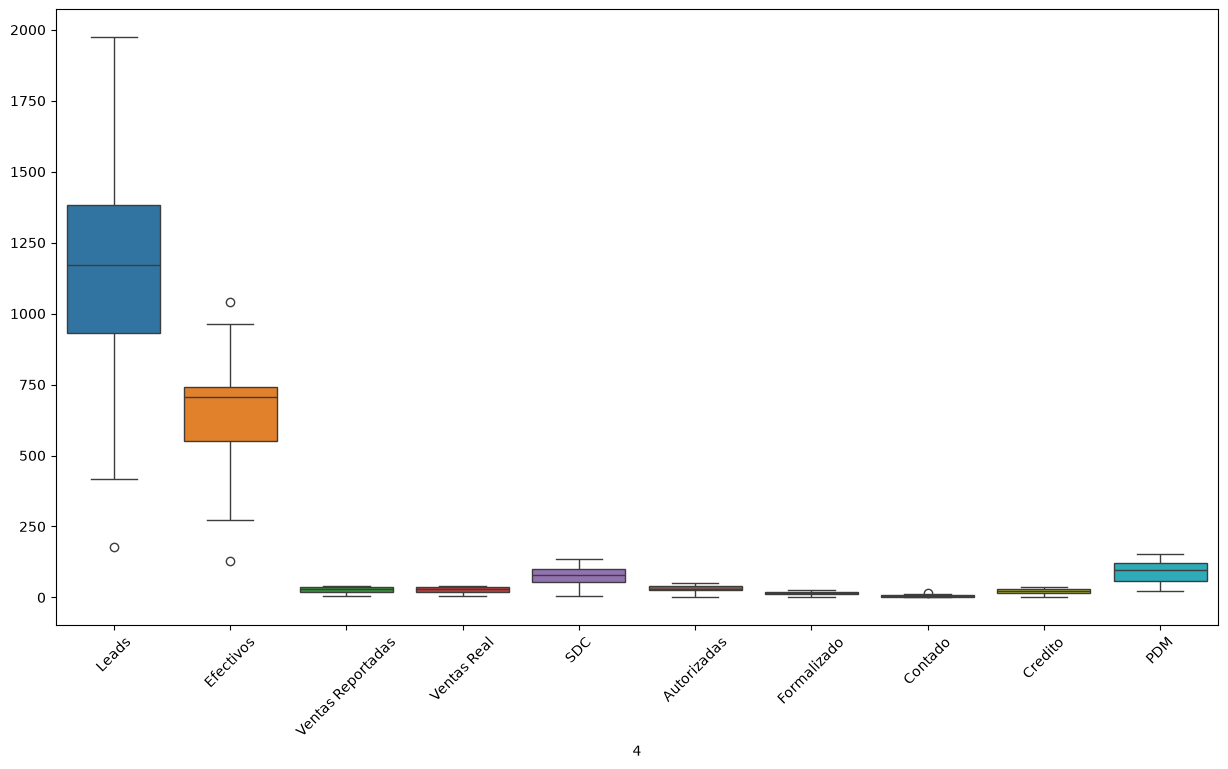

In [24]:
# Seleccionamos únicamente las variables cuantitativas para analizar valores atípicos

cuantitativas = data[
    ['Leads',
     'Efectivos',
     'Ventas Reportadas',
     'Ventas Real',
     'SDC',
     'Autorizadas',
     'Formalizado',
     'Contado',
     'Credito',
     'PDM']
]

# Realizamos un diagrama de caja para identificar valores atípicos

plt.figure(figsize=(15, 8))
sns.boxplot(data=cuantitativas)
plt.xticks(rotation=45)
plt.show()

In [25]:
# Calculamos los límites para identificar valores atípicos mediante IQR

Q1 = cuantitativas.quantile(0.25)
Q3 = cuantitativas.quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Identificamos y contamos los valores atípicos

outliers = (
    (cuantitativas < limite_inferior) |
    (cuantitativas > limite_superior)
)

outliers.sum()

4
Leads                1
Efectivos            2
Ventas Reportadas    0
Ventas Real          0
SDC                  0
Autorizadas          0
Formalizado          0
Contado              1
Credito              0
PDM                  0
dtype: int64

In [26]:
# Mostramos las observaciones que contienen valores atípicos

data[outliers.any(axis=1)]

4,Año,Mes,Leads,Efectivos,Ventas Reportadas,Ventas Real,SDC,Autorizadas,Formalizado,Contado,Credito,PDM
1,2024,Marzo,178,128,7,7,11,7,5,4,3,25
9,2024,Noviembre,1562,1040,22,22,76,25,14,4,18,92
28,2026,Junio,1315,754,37,37,82,35,12,14,26,128


In [27]:
# Exportamos la base de datos limpia

data.to_csv('Resumen_Limpio.csv', index=False)

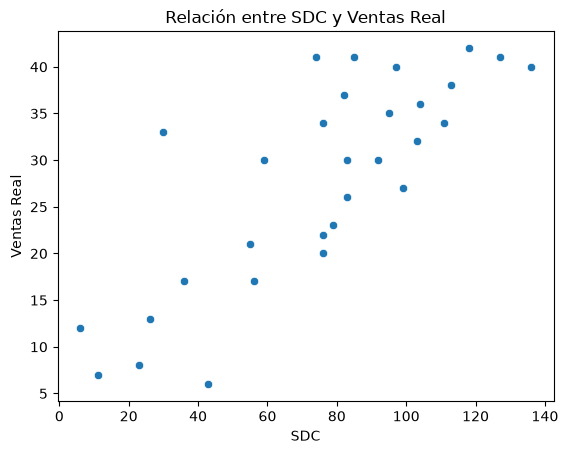

In [28]:
# Graficamos la dispersión entre SDC y Ventas Real
# para observar el comportamiento de ambas variables

sns.scatterplot(x='SDC', y='Ventas Real', data=data)

plt.title('Relación entre SDC y Ventas Real')
plt.xlabel('SDC')
plt.ylabel('Ventas Real')
plt.show()

In [29]:
# Declaramos las variables independiente y dependiente
# para la regresión lineal

Vars_Indep = data[['SDC']]
Var_Dep = data['Ventas Real']

In [30]:
# Importamos la función de regresión lineal

from sklearn.linear_model import LinearRegression

In [31]:
# Definimos el modelo de regresión lineal

model = LinearRegression()

In [32]:
# Ajustamos el modelo con las variables antes declaradas

model.fit(X=Vars_Indep, y=Var_Dep)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.26]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['SDC']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,8.091
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [33]:
# Verificamos los coeficientes obtenidos para el modelo ajustado

model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'tol': 1e-06,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['SDC'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([0.26187629]),
 'rank_': np.int64(1),
 'singular_': array([185.02288147]),
 'intercept_': np.float64(8.091027883046223)}

In [ ]:
### Modelo matemático
### Ventas Real = 8.0910 + 0.2619(SDC)

In [34]:
# Calculamos el coeficiente de determinación R²

model.score(Vars_Indep, Var_Dep)

0.6457955193953697

In [35]:
# Realizamos las predicciones con el modelo ajustado

y_pred = model.predict(X=data[['SDC']])

y_pred

array([ 9.66228564, 10.9716671 , 14.11418261, 14.89981149, 19.35170846,
       22.49422398, 17.51857442, 22.75610027, 28.779255  , 27.99362612,
       35.06428602, 29.82676017, 27.99362612, 32.1836468 , 23.54172915,
       27.99362612, 33.49302826, 35.32616231, 34.01678085, 41.34931704,
       43.70620368, 38.99243041, 37.15929636, 37.68304895, 29.82676017,
       30.35051275, 27.46987354, 32.96927568, 29.56488388, 15.94731666])

In [36]:
# Agregamos la columna de predicciones al DataFrame

data.insert(0, 'Predicciones', y_pred)

data

4,Predicciones,Año,Mes,Leads,Efectivos,Ventas Reportadas,Ventas Real,SDC,Autorizadas,Formalizado,Contado,Credito,PDM
0,9.662286,2024,Febrero,543,389,12,12,6,2,1,10,1,24
1,10.971667,2024,Marzo,178,128,7,7,11,7,5,4,3,25
2,14.114183,2024,Abril,416,288,8,8,23,14,11,2,6,35
3,14.899811,2024,Mayo,422,274,13,13,26,8,3,3,10,54
4,19.351708,2024,Junio,967,620,6,6,43,13,6,0,6,54
5,22.494224,2024,Julio,954,570,21,21,55,30,17,7,14,58
6,17.518574,2024,Agosto,1409,546,17,17,36,19,9,2,15,61
7,22.756100,2024,Septiembre,1315,530,17,17,56,26,7,6,11,75
8,28.779255,2024,Octubre,1973,822,23,23,79,31,14,2,21,57
9,27.993626,2024,Noviembre,1562,1040,22,22,76,25,14,4,18,92


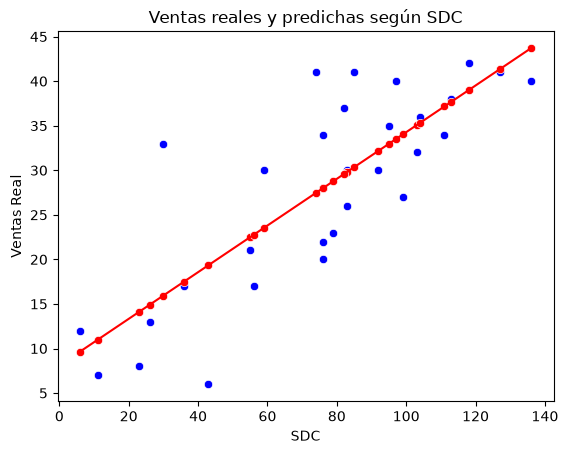

In [37]:
# Graficamos los valores reales y los valores predichos

sns.scatterplot(x='SDC', y='Ventas Real', color="blue", data=data)
sns.scatterplot(x='SDC', y='Predicciones', color="red", data=data)
sns.lineplot(x='SDC', y='Predicciones', color="red", data=data)

plt.title('Ventas reales y predichas según SDC')
plt.xlabel('SDC')
plt.ylabel('Ventas Real')
plt.show()

In [38]:
# Calculamos nuevamente el coeficiente de determinación R²

coef_Deter = model.score(X=Vars_Indep, y=Var_Dep)

coef_Deter

0.6457955193953697

In [39]:
# Calculamos el coeficiente de correlación

coef_Correl = np.sqrt(coef_Deter)

coef_Correl

np.float64(0.8036140363354598)

In [40]:
# Seleccionamos únicamente las variables numéricas para el análisis

data_num = data.select_dtypes(include=np.number)

data_num

4,Predicciones,Año,Leads,Efectivos,Ventas Reportadas,Ventas Real,SDC,Autorizadas,Formalizado,Contado,Credito,PDM
0,9.662286,2024,543,389,12,12,6,2,1,10,1,24
1,10.971667,2024,178,128,7,7,11,7,5,4,3,25
2,14.114183,2024,416,288,8,8,23,14,11,2,6,35
3,14.899811,2024,422,274,13,13,26,8,3,3,10,54
4,19.351708,2024,967,620,6,6,43,13,6,0,6,54
5,22.494224,2024,954,570,21,21,55,30,17,7,14,58
6,17.518574,2024,1409,546,17,17,36,19,9,2,15,61
7,22.756100,2024,1315,530,17,17,56,26,7,6,11,75
8,28.779255,2024,1973,822,23,23,79,31,14,2,21,57
9,27.993626,2024,1562,1040,22,22,76,25,14,4,18,92


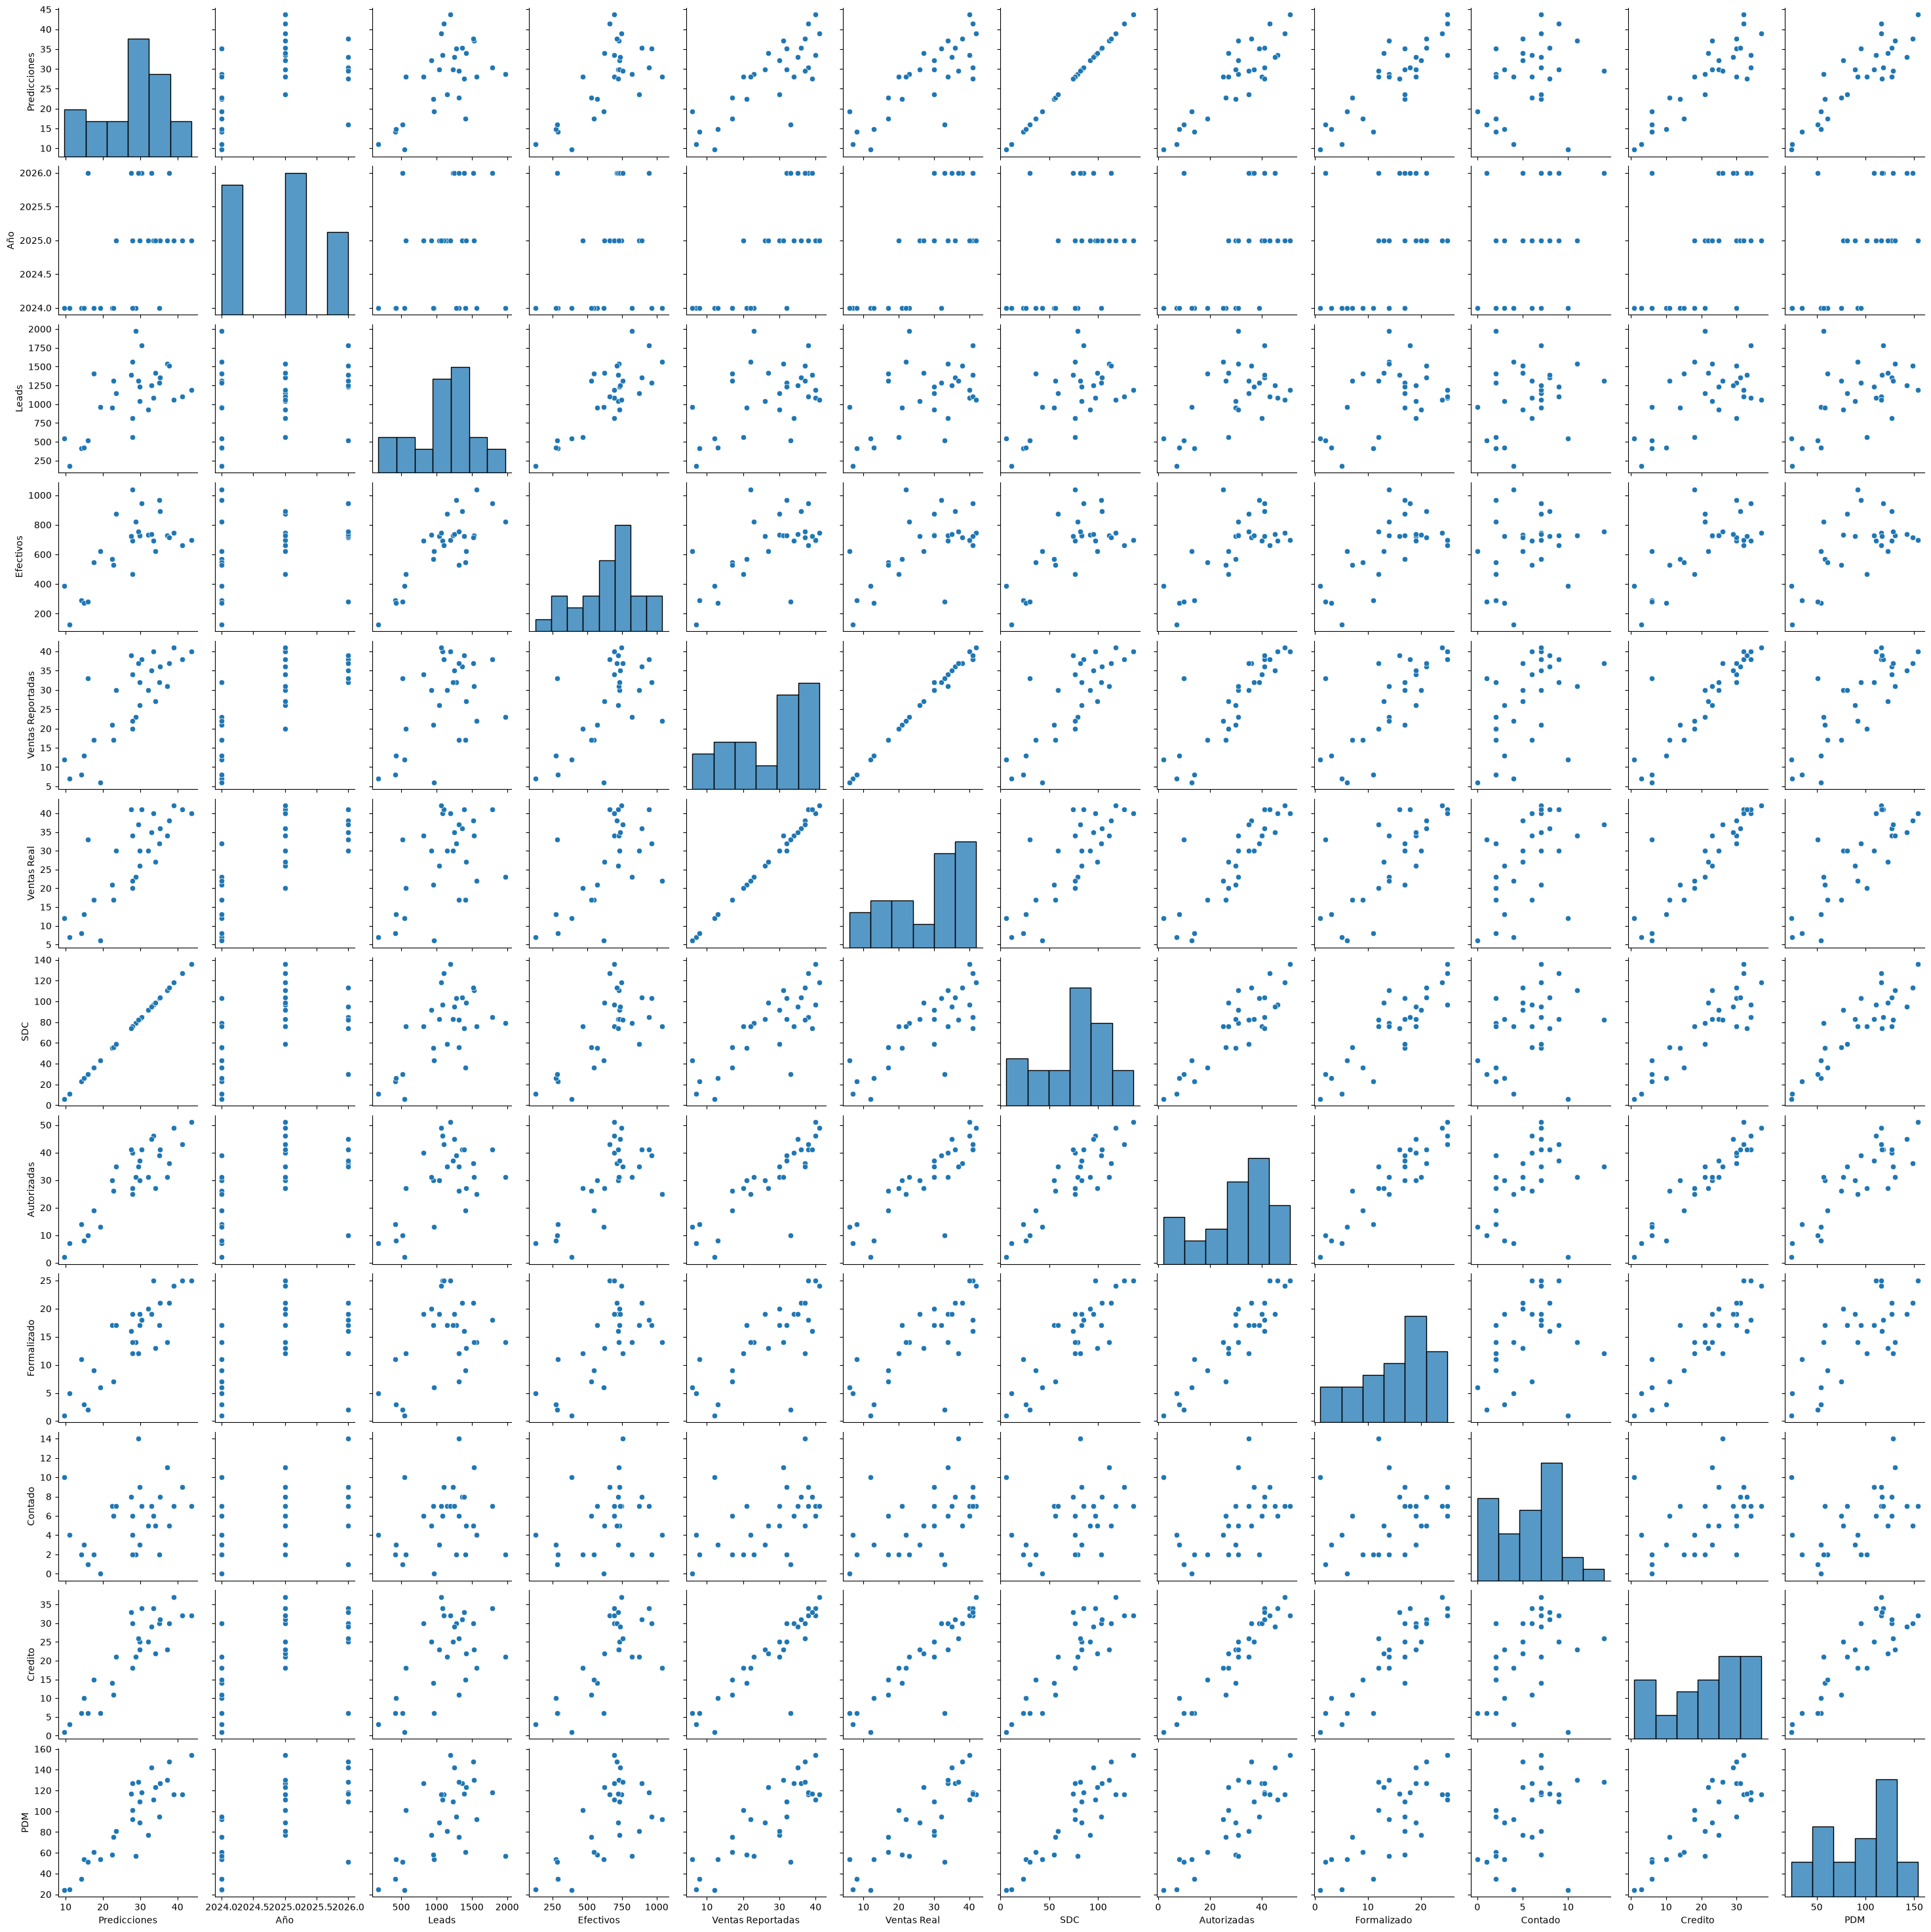

In [41]:
# Graficamos las relaciones entre todas las variables numéricas

sns.pairplot(data_num)

In [42]:
# Calculamos la matriz de correlaciones

Corr_Factors = data_num.corr()

Corr_Factors

4,Predicciones,Año,Leads,Efectivos,Ventas Reportadas,Ventas Real,SDC,Autorizadas,Formalizado,Contado,Credito,PDM
4,,,,,,,,,,,,
Predicciones,1.000000,0.450727,0.591564,0.687552,0.800462,0.803614,1.000000,0.880765,0.860578,0.346054,0.883199,0.876625
Año,0.450727,1.000000,0.255006,0.271705,0.751604,0.746333,0.450727,0.512778,0.386700,0.433478,0.570264,0.667288
Leads,0.591564,0.255006,1.000000,0.809103,0.485889,0.497176,0.591564,0.567387,0.439680,0.245954,0.579861,0.545613
Efectivos,0.687552,0.271705,0.809103,1.000000,0.604369,0.600694,0.687552,0.715662,0.647969,0.271032,0.726229,0.611646
Ventas Reportadas,0.800462,0.751604,0.485889,0.604369,1.000000,0.995965,0.800462,0.861796,0.760830,0.489612,0.898515,0.826245
Ventas Real,0.803614,0.746333,0.497176,0.600694,0.995965,1.000000,0.803614,0.855222,0.756545,0.499711,0.899619,0.825500
SDC,1.000000,0.450727,0.591564,0.687552,0.800462,0.803614,1.000000,0.880765,0.860578,0.346054,0.883199,0.876625
Autorizadas,0.880765,0.512778,0.567387,0.715662,0.861796,0.855222,0.880765,1.000000,0.919922,0.413551,0.951793,0.843840
Formalizado,0.860578,0.386700,0.439680,0.647969,0.760830,0.756545,0.860578,0.919922,1.000000,0.303643,0.890035,0.733133


In [43]:
# Obtenemos el valor absoluto de las correlaciones

Corr_Factors1 = abs(Corr_Factors)

Corr_Factors1

4,Predicciones,Año,Leads,Efectivos,Ventas Reportadas,Ventas Real,SDC,Autorizadas,Formalizado,Contado,Credito,PDM
4,,,,,,,,,,,,
Predicciones,1.000000,0.450727,0.591564,0.687552,0.800462,0.803614,1.000000,0.880765,0.860578,0.346054,0.883199,0.876625
Año,0.450727,1.000000,0.255006,0.271705,0.751604,0.746333,0.450727,0.512778,0.386700,0.433478,0.570264,0.667288
Leads,0.591564,0.255006,1.000000,0.809103,0.485889,0.497176,0.591564,0.567387,0.439680,0.245954,0.579861,0.545613
Efectivos,0.687552,0.271705,0.809103,1.000000,0.604369,0.600694,0.687552,0.715662,0.647969,0.271032,0.726229,0.611646
Ventas Reportadas,0.800462,0.751604,0.485889,0.604369,1.000000,0.995965,0.800462,0.861796,0.760830,0.489612,0.898515,0.826245
Ventas Real,0.803614,0.746333,0.497176,0.600694,0.995965,1.000000,0.803614,0.855222,0.756545,0.499711,0.899619,0.825500
SDC,1.000000,0.450727,0.591564,0.687552,0.800462,0.803614,1.000000,0.880765,0.860578,0.346054,0.883199,0.876625
Autorizadas,0.880765,0.512778,0.567387,0.715662,0.861796,0.855222,0.880765,1.000000,0.919922,0.413551,0.951793,0.843840
Formalizado,0.860578,0.386700,0.439680,0.647969,0.760830,0.756545,0.860578,0.919922,1.000000,0.303643,0.890035,0.733133


<Axes: xlabel='4', ylabel='4'>

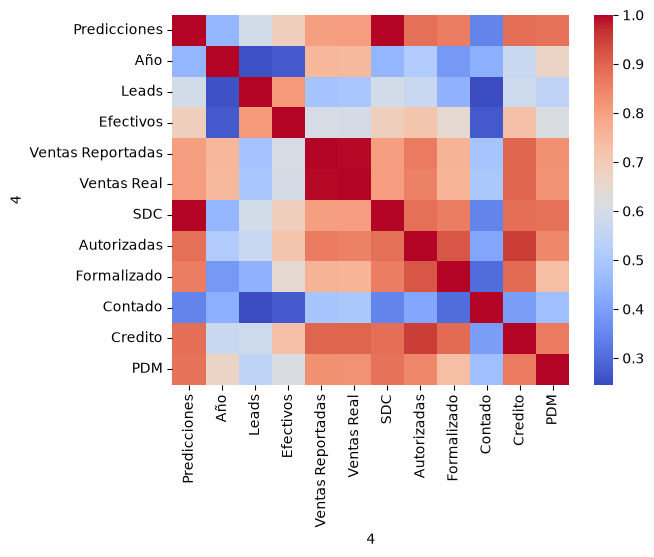

In [44]:
# Graficamos el mapa de calor de las correlaciones

Heat_Map = sns.heatmap(Corr_Factors1, cmap='coolwarm')

Heat_Map

<Axes: xlabel='4', ylabel='4'>

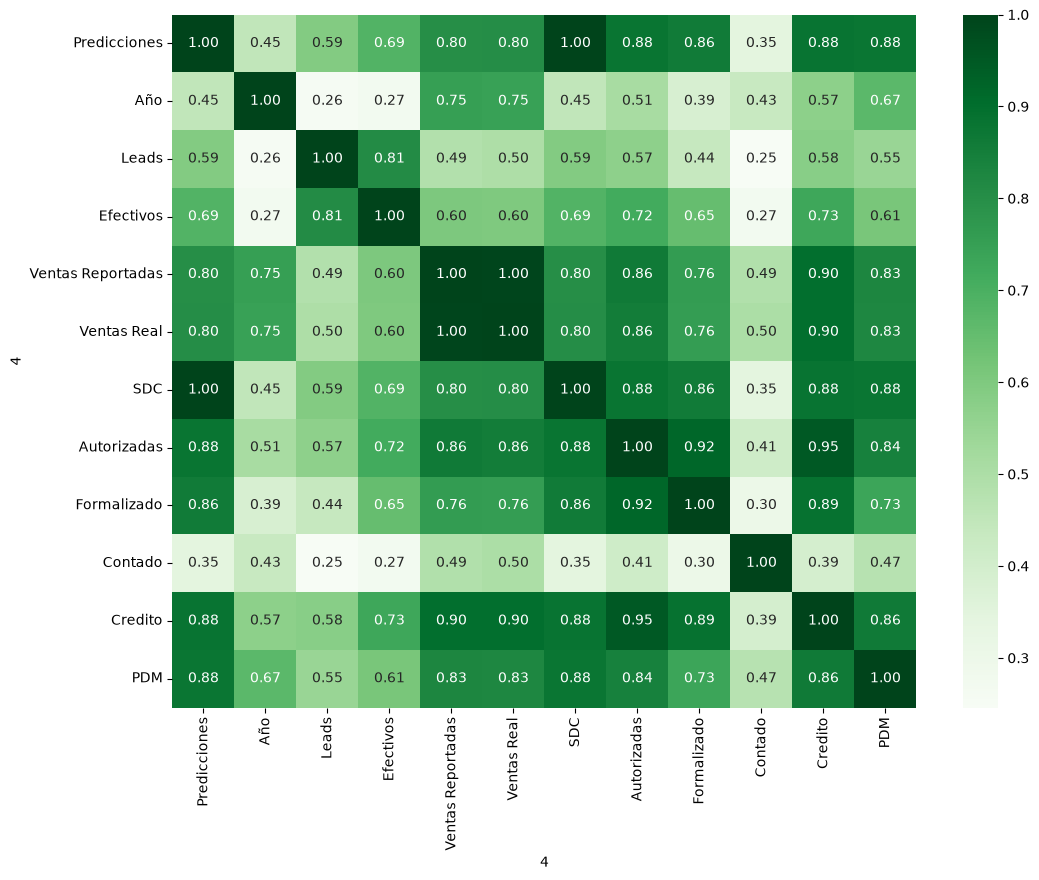

In [45]:
# Graficamos el mapa de calor con los valores de correlación

plt.figure(figsize=(12, 9))

Heat_Map = sns.heatmap(
    Corr_Factors1,
    cmap='Greens',
    annot=True,
    fmt=".2f"
)

Heat_Map